In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from uncertainties import ufloat

# The correct planet mass

In [4]:
jupiter_mass = ufloat(9.547919e-4,0.000002e-4) ## in solar masses

# There is no way to include asymmetric errors in uncertainties
# 4.9 is the mass in jupiter masses
Wispit_mass_upper = ufloat(4.9,0.9)*jupiter_mass
Wispit_mass_lower = ufloat(4.9, 0.6)*jupiter_mass

print("WISPIT 2 planet mass = ", round(Wispit_mass_upper.n,4), " + ",round(Wispit_mass_upper.s,4), " - ", round(Wispit_mass_lower.s,4), "Solar masses")


WISPIT 2 planet mass =  0.0047  +  0.0009  -  0.0006 Solar masses


We make three planet files: WISPIT_lower.cfg, WISPIT_middle.cfg, and WISPIT_upper.cfg for the lower limit of the confidence interval, the middle, and the upper limit.

# The correct SIGMA SLOPE

In [5]:
# I guess we take 1 for now??

# The correct flaring index

## Optical depth along the vertical axis
We know that the visible surface has a flaring index of 1.77 in the H-Band and 2.22 in the K-Band. The refernce point is $r = 163.6$ au, $h = 24.0$ au, so

In [6]:
H = 24.0/163.6
print(H)

0.1466992665036675


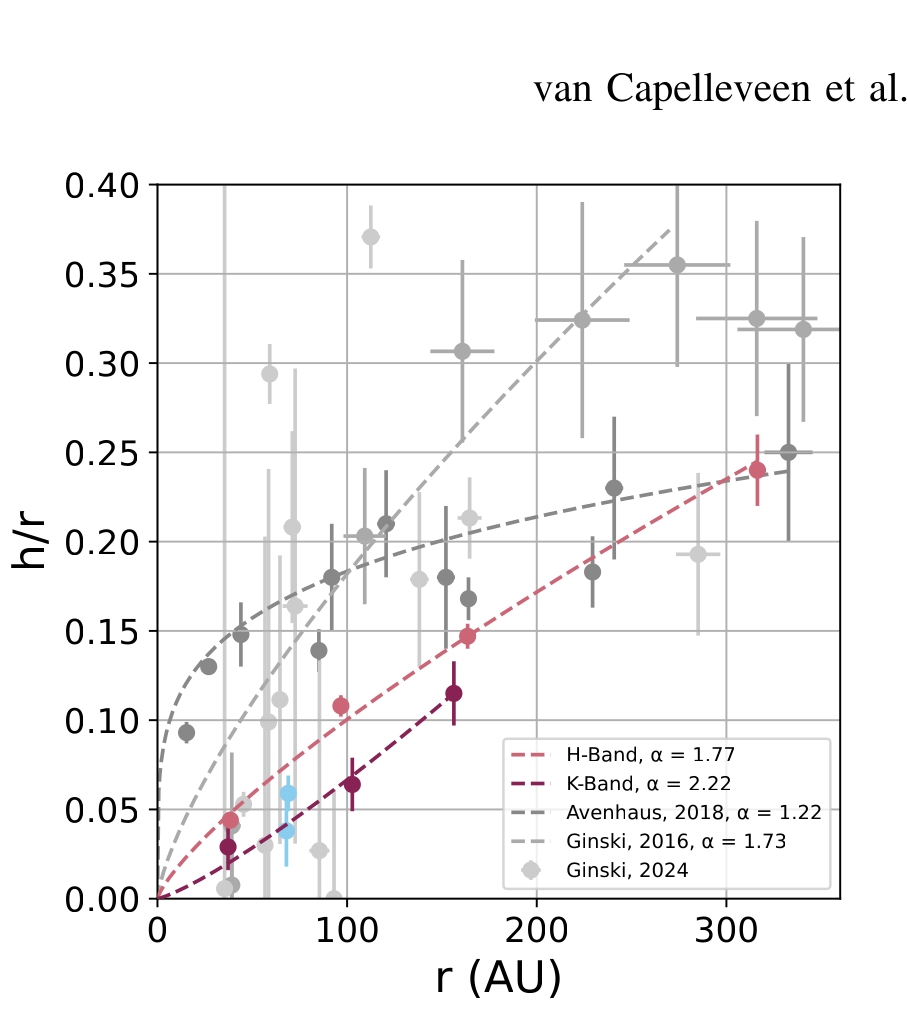

Now, we'd expect the scattering surface to occur at some constant value of optical depth. Optical depth is a product of $\kappa$ (for the respective wavelength) and the density. In the 3d model, the 2d-density is smeared out with a gaussian profile in the z direction. So the height of the scattering surface depends on the surface density *and* the pressure scale height at that point.

Let's say for now that the scattering surface is at some arbirary value of $\tau = 1$ (We just want to make a rough estimate). Then we must have

$$\tau = \int_{h_{scat}}^{\infty} \kappa \rho(z) dz = \int_{h_{scat}}^{\infty} \kappa \rho_0 \exp(-z^2/2h^2)$$

Where $h = c_s/\Omega_k$ is the pressure scale height and $\rho_0 = \frac{1}{\sqrt{2\pi}} \frac{\Sigma}{h}$. Now,
$\Sigma \propto r^{-\sigma}$ for a value of $\sigma$ as Sigmaslope.

Now, we can solve numerically for $h_{scat}$. (The end goal is to see how $\sigma$, the flaring index in the power law for the aspect ratio and the power law (if there even is one) for $h_{scat}$ are related.

In [151]:
from scipy.special import erfc, erf

sigslope = 1.0
flaring_index = 1/4

r = np.power(10,np.linspace(-1,3,100)) # au

# start with 1.7e3 g/cm² at 1 au, from the minimum mass solar nebula.
sigma_0 = 1.7e3 # g/cm²
sigma_gas = sigma_0* np.power(r, -sigslope)
# dust
sigma = sigma_gas * 0.01
# start with h = 0.06 aspect ratio at 100 au
h_0 = 0.09
h = h_0 * np.power(r/100, flaring_index)

H = h*r

rho_0 = sigma/np.sqrt(2*np.pi)/h

kappa = 327.86636079024055 # that's kappa_tot_K in cm²/g

def tau_from_h_scat(hscat, sigma, H):
    return kappa*erfc(hscat/H/np.sqrt(2))*sigma*0.5


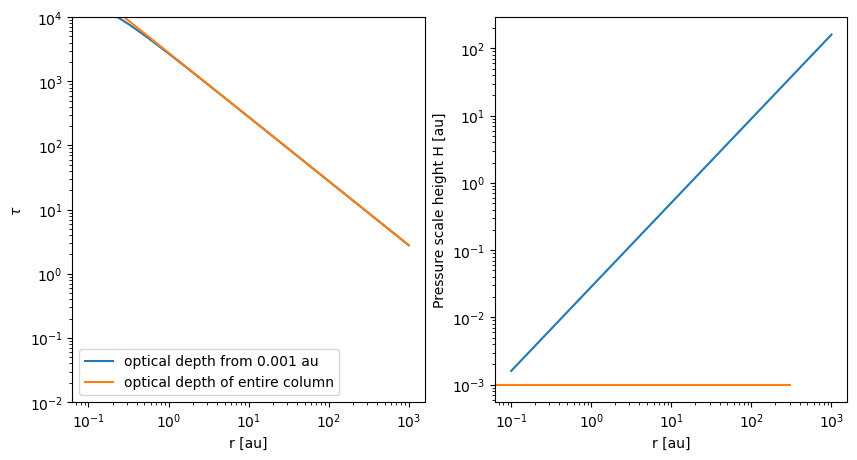

In [152]:
hs =01e-3
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(r, tau_from_h_scat(hs, sigma,H), label=f"optical depth from {hs} au")
# divide by 2 because we only consider the optical depth of the upper hemisphere.
plt.plot(r, sigma*kappa/2, label="optical depth of entire column")
plt.yscale("log")
plt.xscale("log")
plt.ylabel("$\\tau$")
plt.xlabel("r [au]")
plt.ylim([1e-2,1e4])
plt.legend()

plt.subplot(1,2,2)
plt.plot(r, h*r)
plt.ylabel("Pressure scale height H [au]")
plt.xlabel("r [au]")
plt.yscale("log")
plt.xscale("log")
plt.plot([0,300],[hs,hs])


In [153]:
"""
plt.plot(r, sigma*kappa)
plt.yscale("log")
plt.xscale("log")
"""

'\nplt.plot(r, sigma*kappa)\nplt.yscale("log")\nplt.xscale("log")\n'

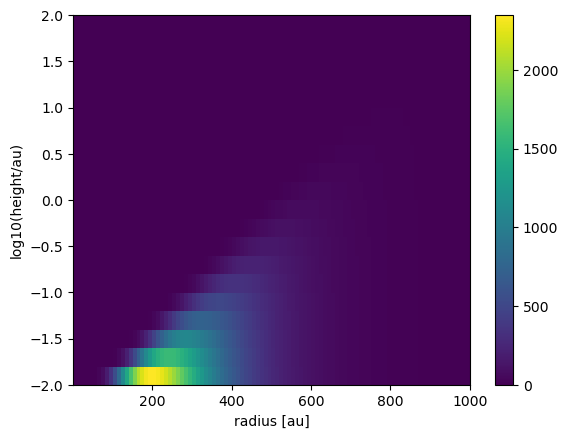

In [154]:
hs_list = np.power(10,np.linspace(-2,2,20))
# first index: h_scat, second index: radius.
taulists = [tau_from_h_scat(hs, sigma,H) for hs in hs_list]
#taulists.append(sigma*kappa)


#R, HS = np.meshgrid(r, hs_list, indexing='ij')

plt.figure()
#plt.pcolormesh(R, HS, taulists, shading='auto')
plt.imshow(taulists, origin="lower",aspect="auto",extent=[r[0], r[-1],np.log10(hs_list[0]), np.log10(hs_list[-1])])
plt.ylabel("log10(height/au)")
plt.xlabel("radius [au]")
plt.colorbar()

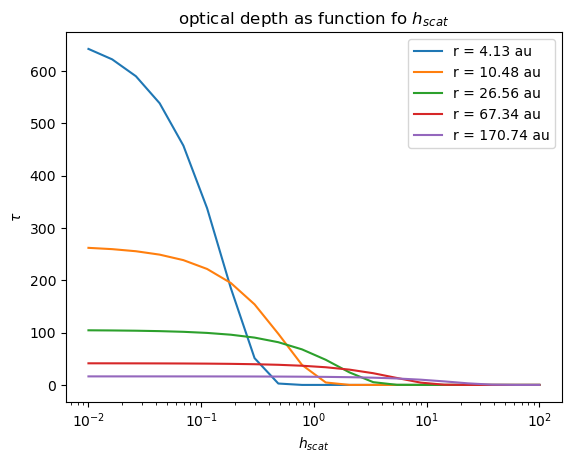

In [155]:
hs_list = np.power(10,np.linspace(-2,2,20))
# first index: h_scat, second index: radius.
taulists = np.array([tau_from_h_scat(hs, sigma,H) for hs in hs_list])

for r_ind in [int(len(r)/10*(i+4)) for i in range(5)]:
    plt.plot(hs_list, taulists[:,r_ind], label=f"r = {round(r[r_ind],2)} au")
#plt.yscale("log")
plt.xscale("log")
plt.xlabel("$h_{scat}$")
plt.ylabel("$\\tau$")
plt.title("optical depth as function fo $h_{scat}$")
plt.legend()

In [156]:
"""
# now, we are more interested in large h_scat
hs_list = np.power(10,np.linspace(-4,3,200))
# first index: h_scat, second index: radius.
taulists = np.array([tau_from_h_scat(hs, sigma,H) for hs in hs_list])

# optical depth at the scattering surface
tau_scats = [0.1,1,10]
h_scats = []
for tau_scat in tau_scats:
    h_scats.append([])
    for i in range(len(r)):
        h_scat_est = np.interp(tau_scat, np.flip(taulists[:,i]), np.flip(hs_list))
        if tau_scat>max(taulists[:,i]):
            h_scat_est = np.nan
        h_scats[-1].append(h_scat_est)
"""

'\n# now, we are more interested in large h_scat\nhs_list = np.power(10,np.linspace(-4,3,200))\n# first index: h_scat, second index: radius.\ntaulists = np.array([tau_from_h_scat(hs, sigma,H) for hs in hs_list])\n\n# optical depth at the scattering surface\ntau_scats = [0.1,1,10]\nh_scats = []\nfor tau_scat in tau_scats:\n    h_scats.append([])\n    for i in range(len(r)):\n        h_scat_est = np.interp(tau_scat, np.flip(taulists[:,i]), np.flip(hs_list))\n        if tau_scat>max(taulists[:,i]):\n            h_scat_est = np.nan\n        h_scats[-1].append(h_scat_est)\n'

In [157]:
def calc_h_scat_uncorrected(tau_scat, hs, sigma, H, r):
    # calculate h_scat for a given tau_scat
    h_scats=[]
    hs_list = np.power(10,np.linspace(-4,3,200))
    taulists = np.array([tau_from_h_scat(hs, sigma,H) for hs in hs_list])
    for i in range(len(r)):
        h_scat_est = np.interp(tau_scat, np.flip(taulists[:,i]), np.flip(hs_list))
        if tau_scat>max(taulists[:,i]):
            h_scat_est = np.nan
        h_scats.append(h_scat_est)
    return h_scats

tau_scats = [0.1,1,10]
h_scats = []
for tau_scat in tau_scats:
    h_scats.append(calc_h_scat_uncorrected(tau_scat, hs, sigma, H, r))

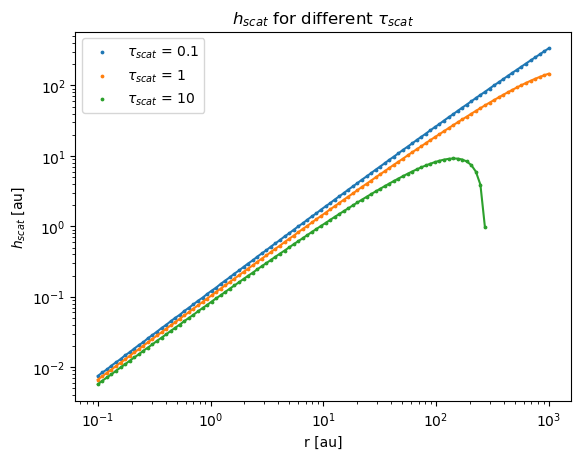

In [158]:
for i in range(len(tau_scats)):
    plt.scatter(r, h_scats[i], s=3, label=f"$\\tau_{{scat}}$ = {tau_scats[i]}")
    plt.plot(r, h_scats[i])
plt.yscale("log")
plt.xscale("log")
plt.ylabel(f"$h_{{scat}}$ [au]")
plt.xlabel("r [au]")
plt.title(f"$h_{{scat}}$ for different $\\tau_{{scat}}$")
plt.legend()

If you consider too few $h_{scats}$ for small values, the figure will get weird bumps because the interpolation doesn't have enough points anymore to make reasonable estimates for small r. This can be fixed quite easily. As you can see, $h_{scat}$ approximately follows a power law, but only for small $\tau_{scat}$ and small $r$. I assume that's because you can taylor the integral we used to compute $\tau$ quite well for larger $h_{scat}/H$.  

In [159]:
"""
for i in range(len(tau_scats)):
    plt.scatter(r, h_scats[i]/H, s=3, label=f"$\\tau_{{scat}}$ = {tau_scats[i]}")
    plt.plot(r, h_scats[i]/H)
plt.yscale("log")
plt.xscale("log")
plt.ylabel(f"$h_{{scat}}/h$")
plt.xlabel("r [au]")
plt.title(f"$h_{{scat}}/h$ for different $\\tau_{{scat}}$")
plt.legend()
"""

'\nfor i in range(len(tau_scats)):\n    plt.scatter(r, h_scats[i]/H, s=3, label=f"$\\tau_{{scat}}$ = {tau_scats[i]}")\n    plt.plot(r, h_scats[i]/H)\nplt.yscale("log")\nplt.xscale("log")\nplt.ylabel(f"$h_{{scat}}/h$")\nplt.xlabel("r [au]")\nplt.title(f"$h_{{scat}}/h$ for different $\\tau_{{scat}}$")\nplt.legend()\n'

Above, you can see $h_{scat}/H$, so the scattering height divided by the pressure scale height. As you can see, they don't follow the same power law, and the power laws also depend on the value of $\tau_{scat}$! But before we investigate further, we have to address some shortcomings of our model.

## Optical depth along line of sight

There is one massive problem with the model in the preceding section: There, we only considered *vertical* optical depth. But the physically relevant number is the optical depth *along the line of sight of the star*! So this is where it gets extra difficult.

We'll try this approximation first:

$$\tau_{line of sight} = \tau_{vertical}/\sin(\alpha) $$
Where $\alpha$ is the scattering angle, so $\tan(\alpha) = h_{scat}/r$.
This assumes the density is the same (on average) along the line of sight and along the vertical axis that we integrated on to obtain $\tau_{vertical}$. This isn't particularly correct, but should give us an idea about the order of magnitude.

In [160]:
def tau_line_of_sight_from_h_scat(hscat, sigma, H,r):
    alpha = np.arctan(hscat/r)
    return tau_from_h_scat(hscat,sigma, H)/0.05#np.sin(alpha) 


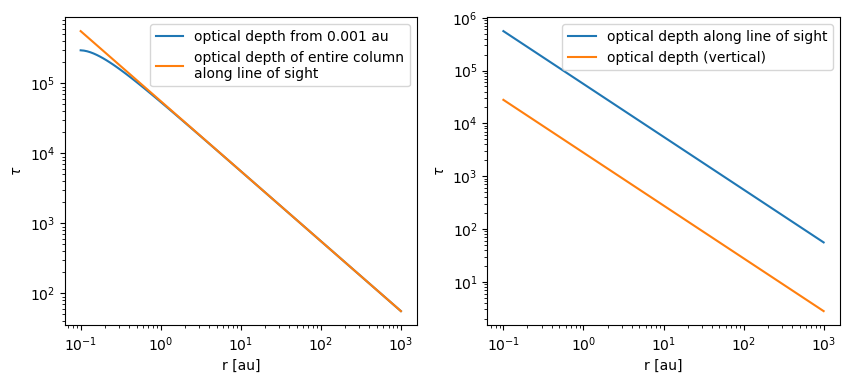

In [161]:
# checking that result is reasonable
plt.figure(figsize=(10,4))
hs =1e-3
plt.subplot(1,2,1)
plt.plot(r, tau_line_of_sight_from_h_scat(hs, sigma,H,r), label=f"optical depth from {hs} au")
# divide by 2 because we only consider the optical depth of the upper hemisphere.
plt.plot(r, sigma*kappa/2/0.05,#/np.sin(np.arctan(hs/r)),
         label="optical depth of entire column\nalong line of sight")
plt.yscale("log")
plt.xscale("log")
plt.ylabel("$\\tau$")
plt.xlabel("r [au]")
plt.legend()
plt.subplot(1,2,2)


# divide by 2 because we only consider the optical depth of the upper hemisphere.
plt.plot(r, sigma*kappa/2/0.05,
         #/np.sin(np.arctan(hs/r)),
         label="optical depth along line of sight")
plt.plot(r, sigma*kappa/2, label="optical depth (vertical)")
plt.yscale("log")
plt.xscale("log")
plt.ylabel("$\\tau$")
plt.xlabel("r [au]")
plt.legend()

Something fishy is happening for large radii, presumably because $\alpha$ gets close to 0°, and thus $\sin(\alpha)$ gets close to 0 and weird things happen . . . But it also doesn't look quite right for small radii.

It is very strange that the optical depth along the line of sight is independent of the radius. Is this a very strange coincidence? Or always the case? I changed the flaring index a bit and the effect remained. (Why is this the case?). I changed sigma slope from 1 to 1.5 and now the optical depth along the line of sight isn't constant anymore. So it seems it's tied to sigma slope? I also tried it for sigmaslope = 1.1 and the optical depth along the line of sight wasn't constant, but with a smaller slope (in the log-log-plot) than for sigmaslope=1.5. It seems that the correction we're using is *also* following a power law, and for sigmaslope=1 the powers add up to 0 by coincidence, hence it is constant. Okay.

In [162]:
"""
plt.plot(r,np.arctan(hs/r))
plt.xscale("log")
plt.ylabel("$\\alpha$ (incidence angle)")
plt.xlabel("r [au]")
"""

'\nplt.plot(r,np.arctan(hs/r))\nplt.xscale("log")\nplt.ylabel("$\\alpha$ (incidence angle)")\nplt.xlabel("r [au]")\n'

In [163]:
"""
plt.plot(r,1/np.sin(np.arctan(hs/r)))
# this is just for comparison, so we can eyeball the slope better. Turns out the slope is pretty much the same!
plt.plot(r, r)
plt.xscale("log")
plt.yscale("log")
plt.ylabel("$1/\\sin(\\alpha)$")
plt.xlabel("r [au]")
"""

'\nplt.plot(r,1/np.sin(np.arctan(hs/r)))\n# this is just for comparison, so we can eyeball the slope better. Turns out the slope is pretty much the same!\nplt.plot(r, r)\nplt.xscale("log")\nplt.yscale("log")\nplt.ylabel("$1/\\sin(\\alpha)$")\nplt.xlabel("r [au]")\n'

~~Perry the Powerlaw?~~ Apparently our correction is also following a power law. This isn't all that surprising, if you think about it. For small $x<<1$, we have $\tan(x) \approx x$, $\sin(x) \approx x$, $\arctan(x) \approx x$, so

$$1/\sin(\alpha) = 1/\sin(\arctan(h_{scat}/r)) \approx 1/\sin(h_{scat}/r) \approx 1/(h_{scat}/r) = r/h_{scat} $$

So it's not surprising we find a power law for $h_{scat}/r <<1$. And since the total (corrected) optical depth along the line of sight is given by $\Sigma*\kappa/\sin(\alpha)$, we get that it does not depend on $r$ for sigmaslope = 1.

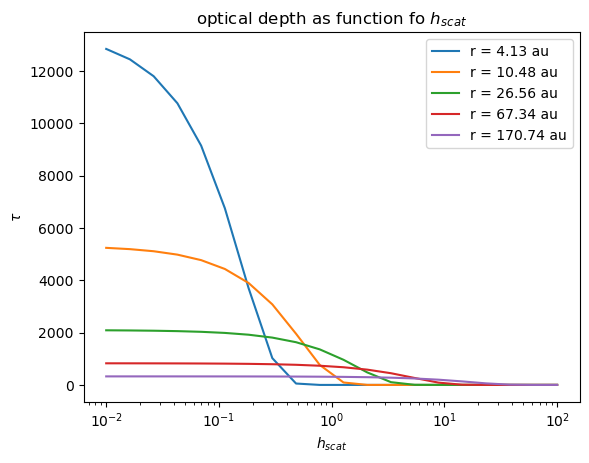

In [164]:
hs_list = np.power(10,np.linspace(-2,2,20))
# first index: h_scat, second index: radius.
taulists = np.array([tau_line_of_sight_from_h_scat(hs, sigma,H,r) for hs in hs_list])

for r_ind in [int(len(r)/10*(i+4)) for i in range(5)]:
    plt.plot(hs_list, taulists[:,r_ind], label=f"r = {round(r[r_ind],2)} au")
#plt.yscale("log")
plt.xscale("log")
plt.xlabel("$h_{scat}$")
plt.ylabel("$\\tau$")
plt.title("optical depth as function fo $h_{scat}$")
plt.legend()

In [165]:
"""
# now, we are more interested in large h_scat
hs_list = np.power(10,np.linspace(-4,3,200))
# first index: h_scat, second index: radius.
taulists = np.array([tau_line_of_sight_from_h_scat(hs, sigma,H,r) for hs in hs_list])

# optical depth at the scattering surface
tau_scats = [0.1,1,10]
h_scats = []
for tau_scat in tau_scats:
    h_scats.append([])
    for i in range(len(r)):
        h_scat_est = np.interp(tau_scat, np.flip(taulists[:,i]), np.flip(hs_list))
        if tau_scat>max(taulists[:,i]):
            h_scat_est = np.nan
        h_scats[-1].append(h_scat_est)
"""

'\n# now, we are more interested in large h_scat\nhs_list = np.power(10,np.linspace(-4,3,200))\n# first index: h_scat, second index: radius.\ntaulists = np.array([tau_line_of_sight_from_h_scat(hs, sigma,H,r) for hs in hs_list])\n\n# optical depth at the scattering surface\ntau_scats = [0.1,1,10]\nh_scats = []\nfor tau_scat in tau_scats:\n    h_scats.append([])\n    for i in range(len(r)):\n        h_scat_est = np.interp(tau_scat, np.flip(taulists[:,i]), np.flip(hs_list))\n        if tau_scat>max(taulists[:,i]):\n            h_scat_est = np.nan\n        h_scats[-1].append(h_scat_est)\n'

In [166]:
def calc_h_scat(tau_scat, sigma, H, r):
    # calculate h_scat for a given tau_scat using not the vertical optical depth, but the optical depth along the line of sight (approximation)
    h_scats=[]
    hs_list = np.power(10,np.linspace(-4,3,200))
    taulists = np.array([tau_line_of_sight_from_h_scat(hs, sigma,H,r) for hs in hs_list])
    for i in range(len(r)):
        h_scat_est = np.interp(tau_scat, np.flip(taulists[:,i]), np.flip(hs_list))
        if tau_scat>max(taulists[:,i]):
            h_scat_est = np.nan
        h_scats.append(h_scat_est)
    return h_scats



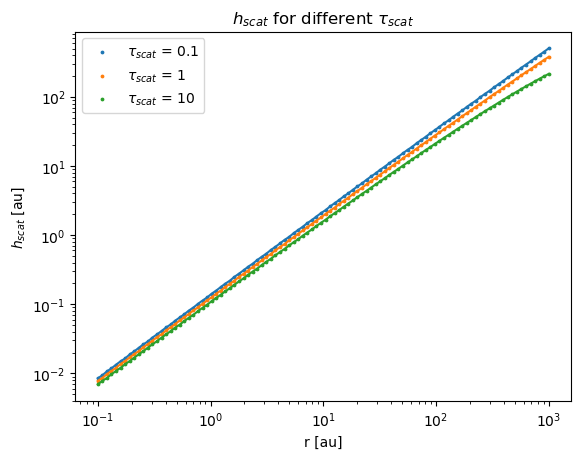

In [167]:
tau_scats = [0.1,1,10]
h_scats = []
for tau_scat in tau_scats:
    h_scats.append(calc_h_scat(tau_scat, sigma, H, r))
    
for i in range(len(tau_scats)):
    plt.scatter(r, h_scats[i], s=3, label=f"$\\tau_{{scat}}$ = {tau_scats[i]}")
    plt.plot(r, h_scats[i])
plt.yscale("log")
plt.xscale("log")
plt.ylabel(f"$h_{{scat}}$ [au]")
plt.xlabel("r [au]")
plt.title(f"$h_{{scat}}$ for different $\\tau_{{scat}}$")
plt.legend()

And that's still a power law! Wonderful. Now the question is, 
- what's the slope? How is it different from before the correction? (Probably differs by 1 in the exponent, since that's the power law for the correction we used)
- Is this approximation good enough for our purposes? What's the deviation compared to the annyoing line integral we could do to get a more accurate value? (Can I make a rough estimate for the error, since I'm too lazy to implement it?)
- Is there maybe a nice power-law form for the scattering surface that depends on sigmaslope and the flaring index? If we find this, we could find some nice constraints for sigmaslope and the flaring index for WISPIT, since we know the power law for the scattering surface for two different wavelengths. This would allow us to make a more accurate simulation.
- Has this been done before by someone else? If I can just use their formula, there's no point in going on here.
- What's the correct $\tau_{scat}$ to use? I'd assume something in the order of magnitude of 1. The choice is probably arbitrary to some degree.

In [168]:
"""
I think this fit is worse than the second one.
Ignore. The values they give for b are pretty similar anyways.
"""
tau_scat = 0.1
h_scat = calc_h_scat(tau_scat, sigma, H, r)
"""


from scipy.optimize import curve_fit
def fit_func(x,a,b):
    return a*np.power(x,b)

# cut out infs and nans
popt, pcov = curve_fit(fit_func, r[7:-4], h_scat[7:-4])

plt.scatter(r, h_scat, s=1)
plt.plot(r, fit_func(r,*popt))
plt.yscale("log")
plt.xscale("log")
plt.title("Fitting directily")
plt.ylabel("$h_{scat}$ [au]")
plt.xlabel("r [au]")

print(f"a = {popt[0]} +- {np.sqrt(pcov[0][0])}")
print(f"b = {popt[1]} +- {np.sqrt(pcov[1][1])}")
"""

'\n\n\nfrom scipy.optimize import curve_fit\ndef fit_func(x,a,b):\n    return a*np.power(x,b)\n\n# cut out infs and nans\npopt, pcov = curve_fit(fit_func, r[7:-4], h_scat[7:-4])\n\nplt.scatter(r, h_scat, s=1)\nplt.plot(r, fit_func(r,*popt))\nplt.yscale("log")\nplt.xscale("log")\nplt.title("Fitting directily")\nplt.ylabel("$h_{scat}$ [au]")\nplt.xlabel("r [au]")\n\nprint(f"a = {popt[0]} +- {np.sqrt(pcov[0][0])}")\nprint(f"b = {popt[1]} +- {np.sqrt(pcov[1][1])}")\n'

a = -1.9575985054024625 +- 0.002794594297451459
b = 1.1890803720223158 +- 0.0007202085375100531


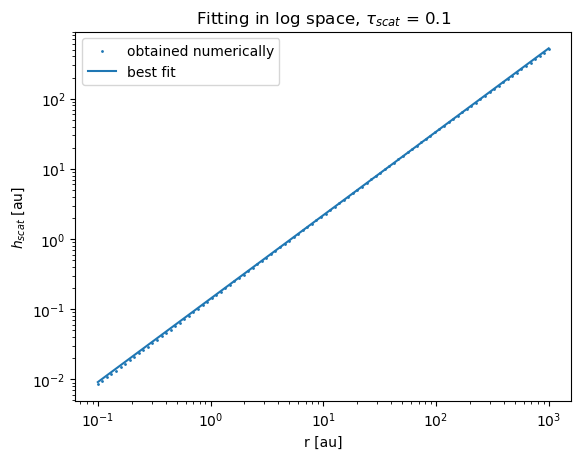

In [169]:
from scipy.optimize import curve_fit
def fit_func_lin(x,a,b):
    return a+x*b

# cut out infs and nans
popt, pcov = curve_fit(fit_func_lin, np.log(r[30:-5]), np.log(h_scat[30:-5]))

plt.scatter(r, h_scat, s=1, label="obtained numerically")
plt.plot(r, np.exp(fit_func_lin(np.log(r),*popt)), label="best fit")
plt.title(f"Fitting in log space, $\\tau_{{scat}}$ = {tau_scat}")
plt.ylabel("$h_{scat}$ [au]")
plt.xlabel("r [au]")
plt.yscale("log")
plt.xscale("log")
plt.legend()

print(f"a = {popt[0]} +- {np.sqrt(pcov[0][0])}")
print(f"b = {popt[1]} +- {np.sqrt(pcov[1][1])}")


Exponent in power law for aspect ratio: 0.25
Exponent in power law for scattering surface:  1.1890803720223158 +- 0.0007202085375100531


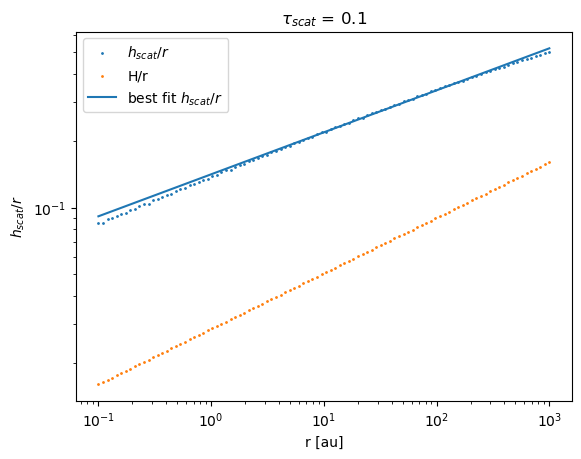

In [170]:
plt.scatter(r, h_scat/r, s=1, label="$h_{scat}/r$")
plt.scatter(r, h, s=1, label="H/r")
plt.plot(r, np.exp(fit_func_lin(np.log(r),*popt))/r, label="best fit $h_{scat}/r$")
plt.title(f"$\\tau_{{scat}}$ = {tau_scat}" )
plt.ylabel("$h_{scat}/r$")
plt.xlabel("r [au]")
plt.yscale("log")
plt.xscale("log")
plt.legend()
print(f"Exponent in power law for aspect ratio: {flaring_index}")
print(f"Exponent in power law for scattering surface:  {popt[1]} +- {np.sqrt(pcov[1][1])}")

Unsurprisingly, the scattering surface is always above one pressure scale height. Thus, $h_{scat}/r > H/r$ everywhere. It's interesting that the scattering surface has a flaring index that differs significantly from the flaring index for the "normal" aspect ratio (the one we got from the pressure scale height) - that's almost a difference of a factor two! This means that for our model, we have to pick a significantly smaller flaring index than the observed 1.8-2.2 (depending on wavelength) that we see for the scattering surface.

Exponent in power law for scattering surface:  1.1957701004924282 +- 0.000648721223705833 (tau_scat = 0.1)
Exponent in power law for scattering surface:  1.178807570303011 +- 0.0010423649854262719 (tau_scat = 1)
Exponent in power law for scattering surface:  1.1584538208381936 +- 0.001716049830443456 (tau_scat = 5)


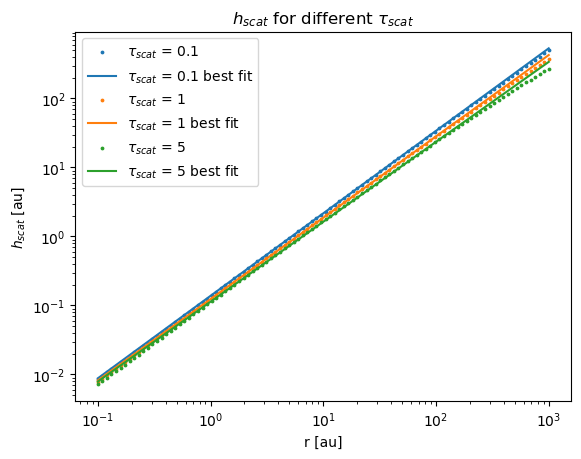

In [171]:
tau_scats = [0.1,1,5]
h_scats = []
for tau_scat in tau_scats:
    h_scats.append(calc_h_scat(tau_scat,sigma, H, r))
    
for i in range(len(tau_scats)):
    plt.scatter(r, h_scats[i], s=3, label=f"$\\tau_{{scat}}$ = {tau_scats[i]}")
    # cut out infs and nans
    popt, pcov = curve_fit(fit_func_lin, np.log(r[10:-10]), np.log(h_scats[i][10:-10]))
    plt.plot(r, np.exp(fit_func_lin(np.log(r),*popt)), label=f"$\\tau_{{scat}}$ = {tau_scats[i]} best fit")

    print(f"Exponent in power law for scattering surface:  {popt[1]} +- {np.sqrt(pcov[1][1])} (tau_scat = {tau_scats[i]})")
    
plt.yscale("log")
plt.xscale("log")
plt.ylabel(f"$h_{{scat}}$ [au]")
plt.xlabel("r [au]")
plt.title(f"$h_{{scat}}$ for different $\\tau_{{scat}}$")
plt.legend()

As we can see, the exponent in the power law doesn't depend very strongly on the $\tau_{scat}$ we choose. This makes it a bit easier, since the choice of $\tau_{scat}$ was very arbitrary to begin with, and now we don't have to worry too much about getting it right --- the errors we're talking about are smaller than 2% (for the exponent).

## power law for scattering surface for different flaring indices

Now, the question of questions: How does the power law for the scattering surface change for different flaring indices? We'll leave sigmaslope constant for now because it's already complicated enough.

In [172]:
from scipy.special import erfc, erf

def make_model(flaring_index, h_0=0.03):

    """
    h_0 is the aspect ratio at 100 au.
    We start with something smallish because it should definitely be smaller than 0.06
    since the scattering surface is always higher than one pressure scale height.
    """
    sigslope = 1.0
    r = np.power(10,np.linspace(-1,3,100)) # au
    # start with 10 g/cm² at 1 au
    sigma_0 = 10 # g/cm²
    sigma = sigma_0* np.power(r, -sigslope)
    # start with h = 0.06 aspect ratio at 100 au
    h_0 = 0.06
    # aspect ratio
    h = h_0 * np.power(r/100, flaring_index)
    # Pressure scale height
    H = h*r

    return r, sigma, h, H

kappa_H = 327.86636079024055 # that's kappa_tot_K in cm²/g


In [173]:
"""
Technically, we don't have to re-define all these functions because no parameters of the model are buried 
in them (except for kappa). I do it anyways so we have them all in one place.
"""

def tau_from_h_scat(hscat, sigma, H, kappa=kappa_H):
    return kappa*erfc(hscat/H/np.sqrt(2))*sigma*0.5

def tau_line_of_sight_from_h_scat(hscat, sigma, H,r, kappa=kappa_H):
    alpha = np.arctan(hscat/r)
    return tau_from_h_scat(hscat,sigma, H, kappa=kappa)/0.05 #/np.sin(alpha)

def calc_h_scat(tau_scat, sigma, H, r, kappa=kappa_H):
    # calculate h_scat for a given tau_scat using not the vertical optical depth, but the optical depth along the line of sight (approximation)
    h_scats=[]
    hs_list = np.power(10,np.linspace(-4,3,200))
    taulists = np.array([tau_line_of_sight_from_h_scat(hs, sigma,H,r, kappa=kappa) for hs in hs_list])
    for i in range(len(r)):
        h_scat_est = np.interp(tau_scat, np.flip(taulists[:,i]), np.flip(hs_list))
        if tau_scat>max(taulists[:,i]):
            h_scat_est = np.nan
        h_scats.append(h_scat_est)
    return h_scats

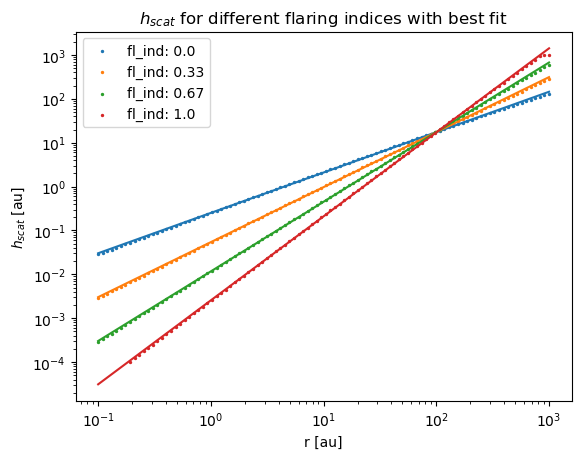

flaring index scattering surface  = a+ b* flaring index
a = 0.9215036610555962 +- 0.0009106514782343075
b = 0.9967399156633601 +- 0.0015352258614455125


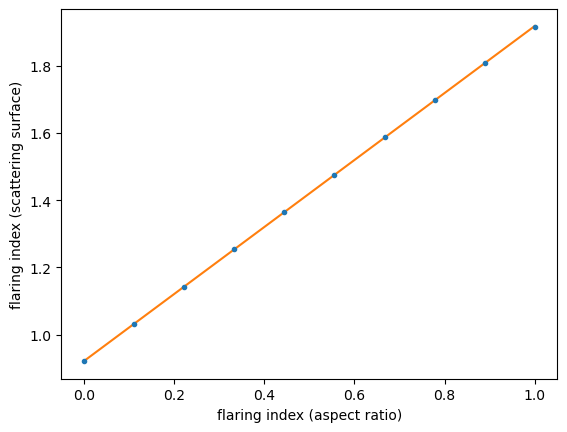

In [174]:
flaring_indices = np.linspace(0.0,1.0, 10)
tau_scat = 1.0 # whatever, as we have seen this choice is not super important.

flaring_ind_scat = []
flaring_ind_scat_err = []

for i,flaring_index in enumerate(flaring_indices):
    r, sigma, h, H = make_model(flaring_index)

    h_scat = np.array(calc_h_scat(tau_scat, sigma, H, r))
    mask = np.isfinite(h_scat)
    popt, pcov = curve_fit(fit_func_lin, np.log(r[mask]), np.log(h_scat[mask]))

    flaring_ind_scat.append(popt[1])
    flaring_ind_scat_err.append(np.sqrt(pcov[1][1]))
    
    if i%3 ==0:
        plt.scatter(r, h_scat, s=2,label=f"fl_ind: {round(flaring_index,2)}")
        plt.plot(r, np.exp(fit_func_lin(np.log(r),*popt)))
   
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.ylabel(f"$h_{{scat}}$ [au]")
plt.xlabel("r [au]")
plt.title(f"$h_{{scat}}$ for different flaring indices with best fit")
plt.show()


popt, pcov = curve_fit(fit_func_lin, flaring_indices, flaring_ind_scat)
plt.errorbar(flaring_indices, flaring_ind_scat, yerr=flaring_ind_scat_err, fmt=".")
plt.plot(flaring_indices, fit_func_lin(flaring_indices, *popt), label="best fit")
plt.xlabel("flaring index (aspect ratio)")
plt.ylabel("flaring index (scattering surface)")

print(f"flaring index scattering surface  = a+ b* flaring index")
print(f"a = {popt[0]} +- {np.sqrt(pcov[0][0])}")
print(f"b = {popt[1]} +- {np.sqrt(pcov[1][1])}")


And we get . . . a linear function? That's simpler than I expected!

I checked briefly, and changing sigma slope alters both a and b. So . . . it's complicated! But let's stick with sigma slope = 1.0 for now. Then, we'd expect

In [175]:
print("flaring index (aspect ratio) K band: ", np.interp( 2.22, flaring_ind_scat, flaring_indices))

flaring_ind_k = np.interp( 2.22, flaring_ind_scat, flaring_indices)

flaring index (aspect ratio) K band:  1.0


And it gets more complicated still: We have only considered one band so far. But there are actually two bands with very different opacities, so this might yet lead to more constraints (or possibly conflicts) for the flaring index *and* sigma slope! Very exciting. We just have to keep in mind that the data we have for the scattering surface is not very good, and our model is simplifying a lot of things. If I want to pursue this more deeply, i definitely have to see how this very simple model compares to a more accurate one that really integrates along the line of sight. I guess the most complete and most difficult approach would be to use Radmc3D to do this, by estimating the scattering surface from the images directly. But that's a lot of work and I'm not sure it's worth the effort - the results might not be much more illuminating than the ones obtained from the simple model.

In any case, the simple model should be good enough to give us at least a decent estimate for the size of the true flaring index and the true aspect ratio at some given radius, which is necessary because fargo3d needs this info. (Did I ever investigate if this makes a difference for the simulation results??? I don't think so. Because if the impact is pretty small, then it's less a question of spirals/no spirals, position of bumps etc. and more a question of where the scattering surface is.)

Another question is: What impact do different flaring indices have on the images? This will be compounded with the effect of different sigma slopes, because both influence the position of the scattering surface . . . Are the effects even that visible under the angle that we're observing WISPIT?


If we do the exact same thing with the other band:

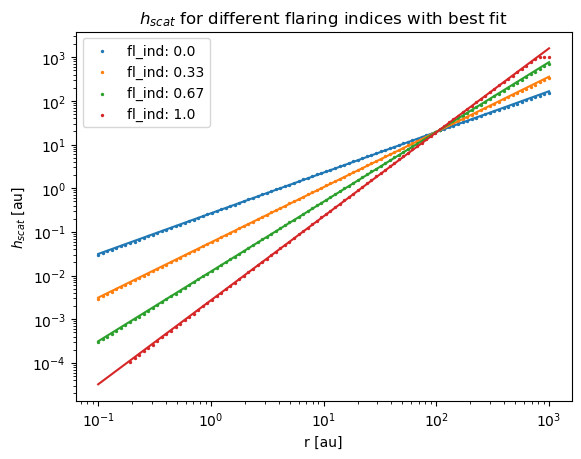

flaring index scattering surface  = a+ b* flaring index
a = 0.9333117547230207 +- 0.0012193216802480749
b = 0.9951937806355381 +- 0.002055598888829308
flaring index (aspect ratio) K band:  1.0
flaring index (aspect ratio) H band:  0.839400681504053


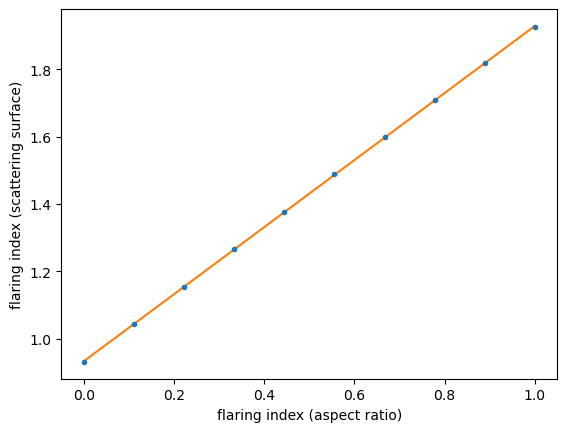

In [177]:
kappa_H = 946.506869910016 #g/cm², now for the H-Band
flaring_indices = np.linspace(0.0,1.0, 10)
tau_scat = 1.0 # whatever, as we have seen this choice is not super important.

flaring_ind_scat = []
flaring_ind_scat_err = []

for i,flaring_index in enumerate(flaring_indices):
    r, sigma, h, H = make_model(flaring_index)

    h_scat = np.array(calc_h_scat(tau_scat, sigma, H, r, kappa = kappa_H))
    mask = np.isfinite(h_scat)
    popt, pcov = curve_fit(fit_func_lin, np.log(r[mask]), np.log(h_scat[mask]))

    flaring_ind_scat.append(popt[1])
    flaring_ind_scat_err.append(np.sqrt(pcov[1][1]))
    
    if i%3 ==0:
        plt.scatter(r, h_scat, s=2,label=f"fl_ind: {round(flaring_index,2)}")
        plt.plot(r, np.exp(fit_func_lin(np.log(r),*popt)))
   
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.ylabel(f"$h_{{scat}}$ [au]")
plt.xlabel("r [au]")
plt.title(f"$h_{{scat}}$ for different flaring indices with best fit")
plt.show()


popt, pcov = curve_fit(fit_func_lin, flaring_indices, flaring_ind_scat)
plt.errorbar(flaring_indices, flaring_ind_scat, yerr=flaring_ind_scat_err, fmt=".")
plt.plot(flaring_indices, fit_func_lin(flaring_indices, *popt), label="best fit")
plt.xlabel("flaring index (aspect ratio)")
plt.ylabel("flaring index (scattering surface)")

print(f"flaring index scattering surface  = a+ b* flaring index")
print(f"a = {popt[0]} +- {np.sqrt(pcov[0][0])}")
print(f"b = {popt[1]} +- {np.sqrt(pcov[1][1])}")

flaring_ind_h = np.interp( 1.77, flaring_ind_scat, flaring_indices)

print("flaring index (aspect ratio) K band: ", flaring_ind_k)
print("flaring index (aspect ratio) H band: ", flaring_ind_h)


Now we have a problem:

In [178]:
print("flaring index (aspect ratio) K band: ", flaring_ind_k)
print("flaring index (aspect ratio) H band: ", flaring_ind_h)


flaring index (aspect ratio) K band:  1.0
flaring index (aspect ratio) H band:  0.839400681504053


These values are very(!) different! I can think of several reasons for this:
- our fits are not the best, since we fitted in the log space, and this might give the small r values too much weight during the fitting. But I don't think that the error created by this is larger than 10%.
- Our model might be too simple to handle the differences that might be going on due to different $\kappa$s correctly.
- The article we took these values from only used 3 or so data points for the k band, so this value is less trustworthy. But even the values we used for the H band only used 5 data points or so, so it's still not great, and the errorbars are quite large for the scattering surface.
- Other people also tried to measure the position of the surface and their measurements don't agree super well with those from the article. If you look at the figure I have included, it looks quite messy.
- We haven't looked at the errors our method realisitically gives yet, but I don't think they're big enough to explain this huuuge difference
- We have only looked at one fixed value for sigma slope. There might be a sigma slope value where both flaring indices match. That would be very cool, because then we have really strong constraints for sigma slope and the flaring index!
  

## power law for scattering surface for different sigma slopes

In [179]:
from scipy.special import erfc, erf

def make_model(flaring_index, h_0=0.09, sigma_slope=1.0):

    """
    h_0 is the aspect ratio at 100 au.
    We start with something smallish because it should definitely be smaller than 0.06
    since the scattering surface is always higher than one pressure scale height.
    """
    sigslope = sigma_slope
    r = np.power(10,np.linspace(-1,3,100)) # au
    # start with 1.7e3 g/cm² at 1 au (Minimum mass solar nebula)
    sigma_0 = 1.7e3 # g/cm²
    sigma_gas = sigma_0* np.power(r, -sigslope)
    # dust
    sigma = sigma_gas * 0.01
    # aspect ratio
    h = h_0 * np.power(r/100, flaring_index)
    # Pressure scale height
    H = h*r

    return r, sigma, h, H

kappa_K = 327.86636079024055 # that's kappa_tot_K in cm²/g


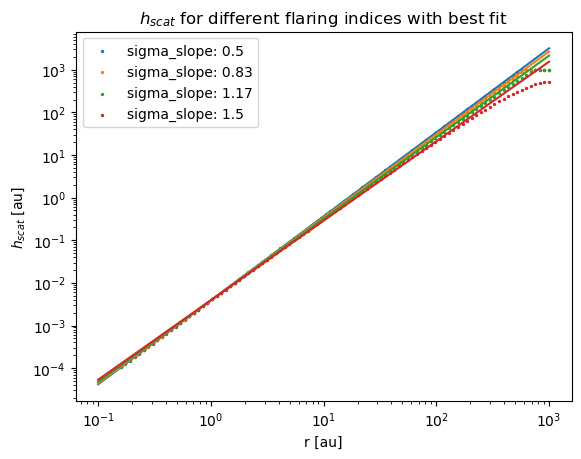

flaring index scattering surface  = a+ b* flaring index
a = 2.0281479513232075 +- 0.005516157172888108
b = -0.10252355313615534 +- 0.005255027869055615


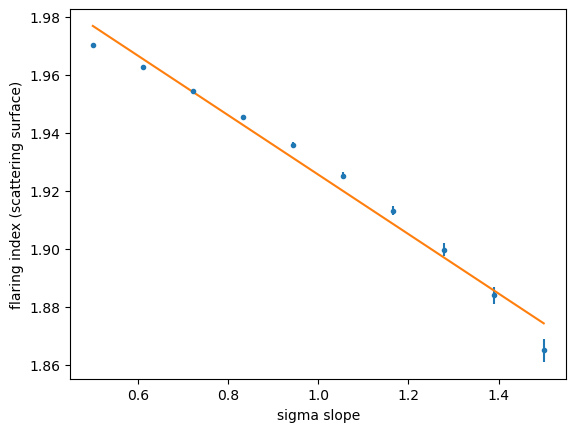

In [180]:
sigma_slopes = np.linspace(0.5,1.5, 10)
tau_scat = 1.0 # whatever, as we have seen this choice is not super important.

flaring_ind_scat = []
flaring_ind_scat_err = []
flaring_index = 1

for i,sigma_slope in enumerate(sigma_slopes):
    r, sigma, h, H = make_model(flaring_index, sigma_slope=sigma_slope)

    h_scat = np.array(calc_h_scat(tau_scat, sigma, H, r))
    mask = np.isfinite(h_scat)
    popt, pcov = curve_fit(fit_func_lin, np.log(r[mask][:-10]), np.log(h_scat[mask][:-10]))

    flaring_ind_scat.append(popt[1])
    flaring_ind_scat_err.append(np.sqrt(pcov[1][1]))
    
    if i%3 ==0:
        plt.scatter(r, h_scat, s=2,label=f"sigma_slope: {round(sigma_slope,2)}")
        plt.plot(r, np.exp(fit_func_lin(np.log(r),*popt)))
   
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.ylabel(f"$h_{{scat}}$ [au]")
plt.xlabel("r [au]")
plt.title(f"$h_{{scat}}$ for different flaring indices with best fit")
plt.show()


popt, pcov = curve_fit(fit_func_lin, sigma_slopes, flaring_ind_scat)
plt.errorbar(sigma_slopes, flaring_ind_scat, yerr=flaring_ind_scat_err, fmt=".")
plt.plot(sigma_slopes, fit_func_lin(sigma_slopes, *popt), label="best fit")
plt.xlabel("sigma slope")
plt.ylabel("flaring index (scattering surface)")

print(f"flaring index scattering surface  = a+ b* flaring index")
print(f"a = {popt[0]} +- {np.sqrt(pcov[0][0])}")
print(f"b = {popt[1]} +- {np.sqrt(pcov[1][1])}")


This is clearly not linear . . . so the story is more complicated. (Aaaah)
Interestingly, sigma slope has a much smaller impact than the flaring index for the aspect ratio: the range of different flaring indices for the scattering surface we can obtain with a fairly large range for sigma slope is not that big.

## Varying sigma slope and the flaring index

In [181]:
sigma_slopes = np.linspace(0.0,1.5, 50)
flaring_indices = np.linspace(0.0,1.6, 50)
tau_scat = 1.0 # whatever, as we have seen this choice is not super important.

kappa_K = 327.86636079024055 # that's kappa_tot_K in cm²/g

flaring_ind_scat = []
flaring_ind_scat_err = []

for i,sigma_slope in enumerate(sigma_slopes):
    flaring_ind_scat.append([])
    flaring_ind_scat_err.append([])
    for j, flaring_index in enumerate(flaring_indices):
        r, sigma, h, H = make_model(flaring_index, sigma_slope=sigma_slope)
    
        h_scat = np.array(calc_h_scat(tau_scat, sigma, H, r, kappa = kappa_K))
        mask = np.isfinite(h_scat)
        ### I think I need a better way of cutting off strange behavior for large r, but I'm too impatient to implement this now.
        popt, pcov = curve_fit(fit_func_lin, np.log(r[mask][:-10]), np.log(h_scat[mask][:-10]))
    
        flaring_ind_scat[-1].append(popt[1])
        flaring_ind_scat_err[-1].append(np.sqrt(pcov[1][1]))


Text(0.5, 0, 'flaring index')

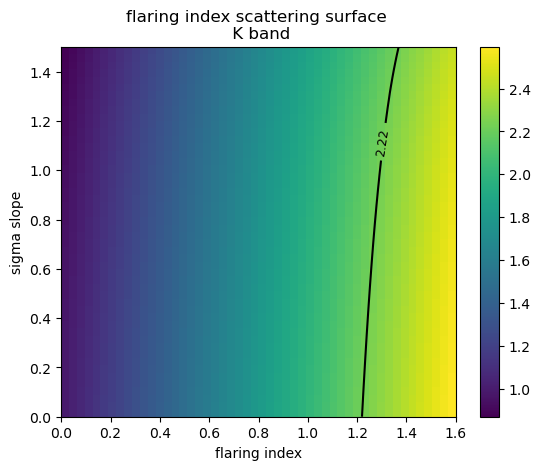

In [182]:
extent = [ flaring_indices[0], flaring_indices[-1],sigma_slopes[0], sigma_slopes[-1],]

# We plot the contour line for the observed value for the power law exponent for the scattering surface in the K band
cs = plt.contour(flaring_ind_scat, cmap="gray", extent=extent, levels = [2.22])

plt.clabel(cs,inline=True,  fontsize=9, fmt="%.2f")
plt.imshow(flaring_ind_scat, origin="lower", aspect="equal",extent=extent)
plt.colorbar()
plt.title("flaring index scattering surface \n K band")
plt.ylabel("sigma slope")
plt.xlabel("flaring index")

In [183]:
# Now, we do the same for the H band
flaring_ind_scat_H = []
flaring_ind_scat_err_H = []

kappa_H = 946.506869910016 #g/cm², now for the H-Band

for i,sigma_slope in enumerate(sigma_slopes):
    flaring_ind_scat_H.append([])
    flaring_ind_scat_err_H.append([])
    for j, flaring_index in enumerate(flaring_indices):
        r, sigma, h, H = make_model(flaring_index, sigma_slope=sigma_slope)
    
        h_scat = np.array(calc_h_scat(tau_scat, sigma, H, r, kappa=kappa_H))
        mask = np.isfinite(h_scat)
        ### I think I need a better way of cutting off strange behavior for large r, but I'm too impatient to implement this now.
        popt, pcov = curve_fit(fit_func_lin, np.log(r[mask][:-10]), np.log(h_scat[mask][:-10]))
    
        flaring_ind_scat_H[-1].append(popt[1])
        flaring_ind_scat_err_H[-1].append(np.sqrt(pcov[1][1]))


Text(0.5, 0, 'flaring index')

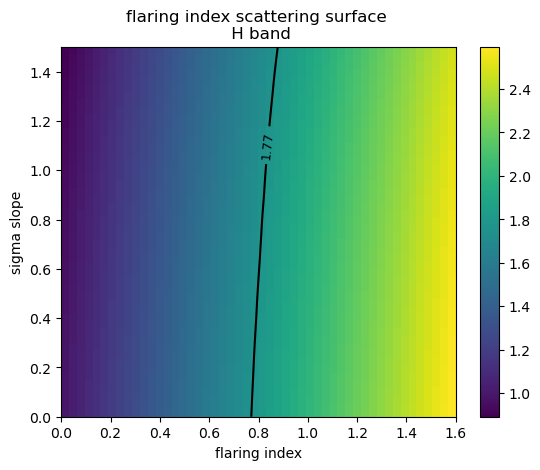

In [184]:
extent = [ flaring_indices[0], flaring_indices[-1],sigma_slopes[0], sigma_slopes[-1],]

# We plot the contour line for the observed value for the power law exponent for the scattering surface in the H band
cs = plt.contour(flaring_ind_scat_H, cmap="gray", extent=extent, levels = [1.77])

plt.clabel(cs,inline=True,  fontsize=9, fmt="%.2f")
plt.imshow(flaring_ind_scat_H, origin="lower", aspect="equal",extent=extent)
plt.colorbar()
plt.title("flaring index scattering surface \n H band")
plt.ylabel("sigma slope")
plt.xlabel("flaring index")

Text(0.5, 0, 'flaring index')

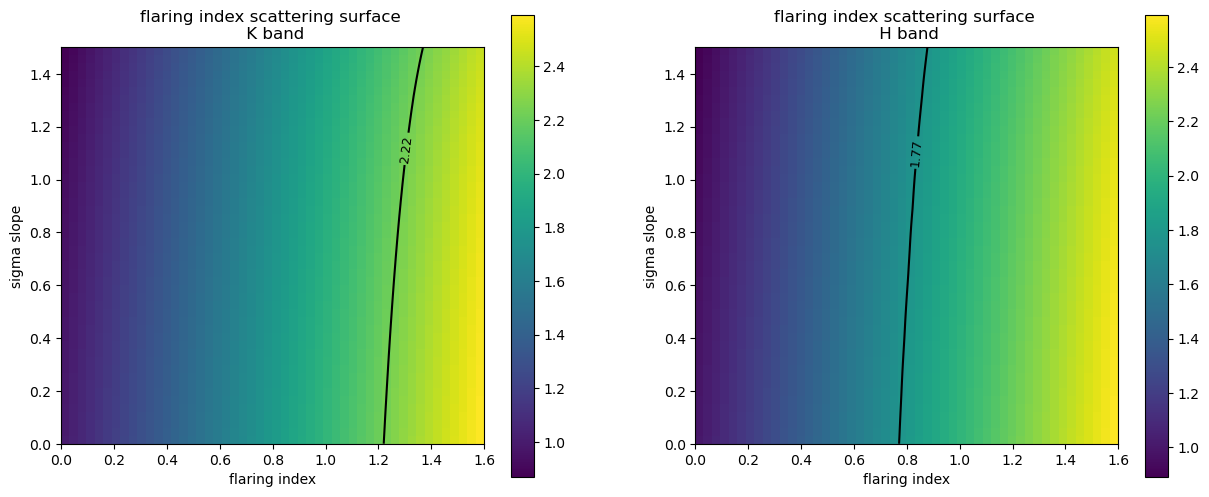

In [185]:
extent = [ flaring_indices[0], flaring_indices[-1],sigma_slopes[0], sigma_slopes[-1],]
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
cs = plt.contour(flaring_ind_scat, cmap="gray", extent=extent, levels = [2.22])
plt.clabel(cs,inline=True,  fontsize=9, fmt="%.2f")
plt.imshow(flaring_ind_scat, origin="lower", aspect="equal",extent=extent)
plt.colorbar()
plt.title("flaring index scattering surface \n K band")
plt.ylabel("sigma slope")
plt.xlabel("flaring index")

plt.subplot(1,2,2)

# We plot the contour line for the observed value for the power law exponent for the scattering surface in the H band
cs = plt.contour(flaring_ind_scat_H, cmap="gray", extent=extent, levels = [1.77])

plt.clabel(cs,inline=True,  fontsize=9, fmt="%.2f")
plt.imshow(flaring_ind_scat_H, origin="lower", aspect="equal",extent=extent)
plt.colorbar()
plt.title("flaring index scattering surface \n H band")
plt.ylabel("sigma slope")
plt.xlabel("flaring index")

As you can see, the two contour lines do not cross, which means that for our current model, we cannot find values for sigma slope and the flaring index such that we observe the exponent 2.22 for the power law of the scattering surface in the K band and 1.77 for the scattering surface in the H band. This could mean various things:
- the model is incorrect/oversimplified
- the data from the article isn't correct
- Aaaaaaaah now I'm more confused than before

Text(0.5, 0, 'flaring index')

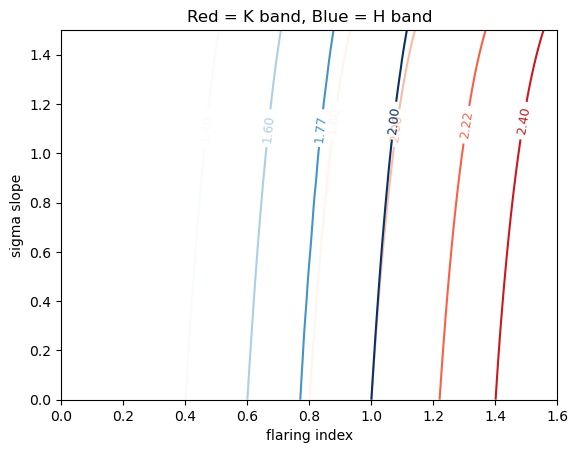

In [186]:
cs = plt.contour(flaring_ind_scat, cmap="Reds", extent=extent, levels = [1.8,2.0,2.22, 2.4, 2.6])
plt.clabel(cs,inline=True,  fontsize=9, fmt="%.2f")
cs = plt.contour(flaring_ind_scat_H, cmap="Blues", extent=extent, levels = [1.4,1.6,1.77, 2.0])
plt.clabel(cs,inline=True,  fontsize=9, fmt="%.2f")
plt.title("Red = K band, Blue = H band")
plt.ylabel("sigma slope")
plt.xlabel("flaring index")

If we have super massive errorbars and the *true* values for the exponents in the power laws are around 2, then there is a region where they match. As we can see, the different opacities that we get for different wavelengths don't make a large difference (at least in this simple model) for the behaviour under changes of sigma slope and the flaring index. So having two different power laws for the two bands doesn't give us much more information than knowing just one. (That's a bit disappointing :( )

And it's still unclear what the correct flaring index/sigma slope is. . . But I guess we can say it must be in the range

flaring index (aspect ratio) K band:  1.4486229392225667


flaring index (aspect ratio) H band:  0.8998705148276459

That's not really narrow though . . . 
And we learn basically nothing about sigma slope because it has such a small impact on the position of the scattering surface.

# What now? Values for the flaring index and the aspect ratio at $R_p$ that hopefully make sense

We will now look at three values for the flaring index in the "reasonable range" we found based on observations.
We will use three different values:

val|lower | middle| upper
----|----|-------|------
flaring index |0.9 | 1.175 | 1.45
$h_0$ | ? | ? | ?

Now we need to find a suitable value for the aspect ratio $h_0$ at $R_p$ so the scattering surface matches the observations fairly well. 

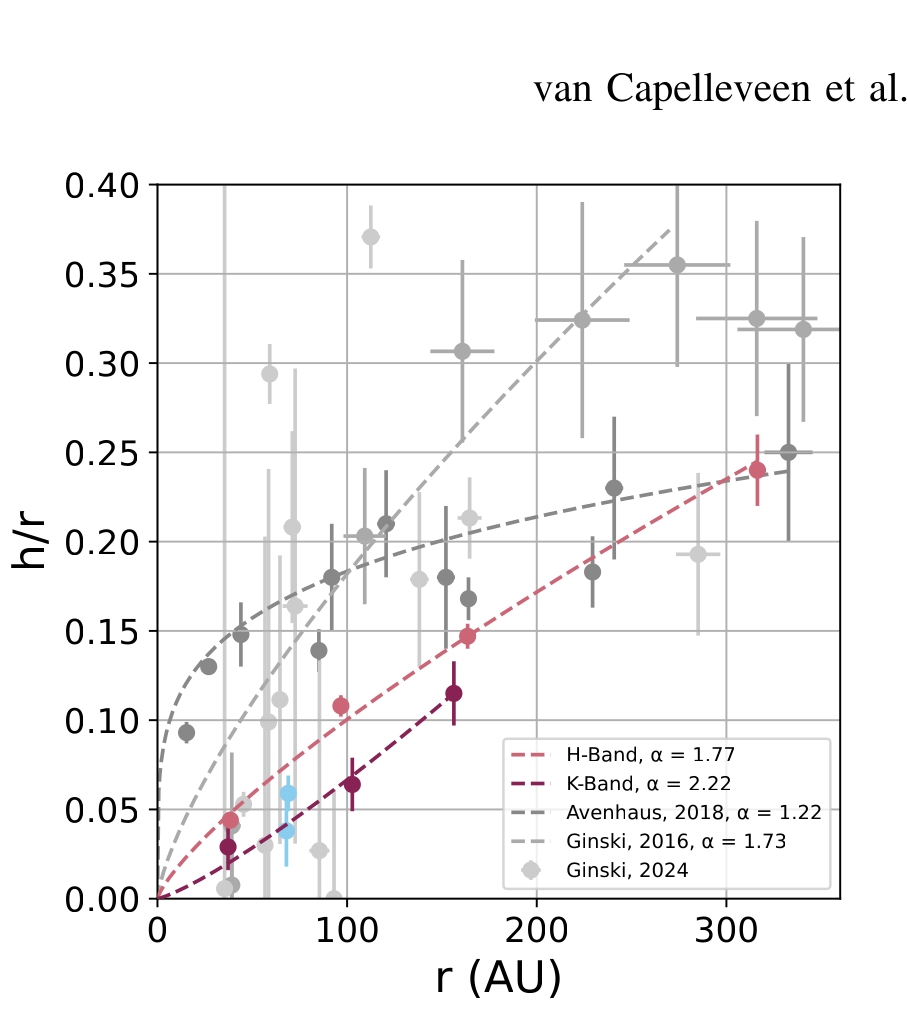

[0.03301344 0.03462907 0.03587532]


Text(0.5, 0, 'r [au]')

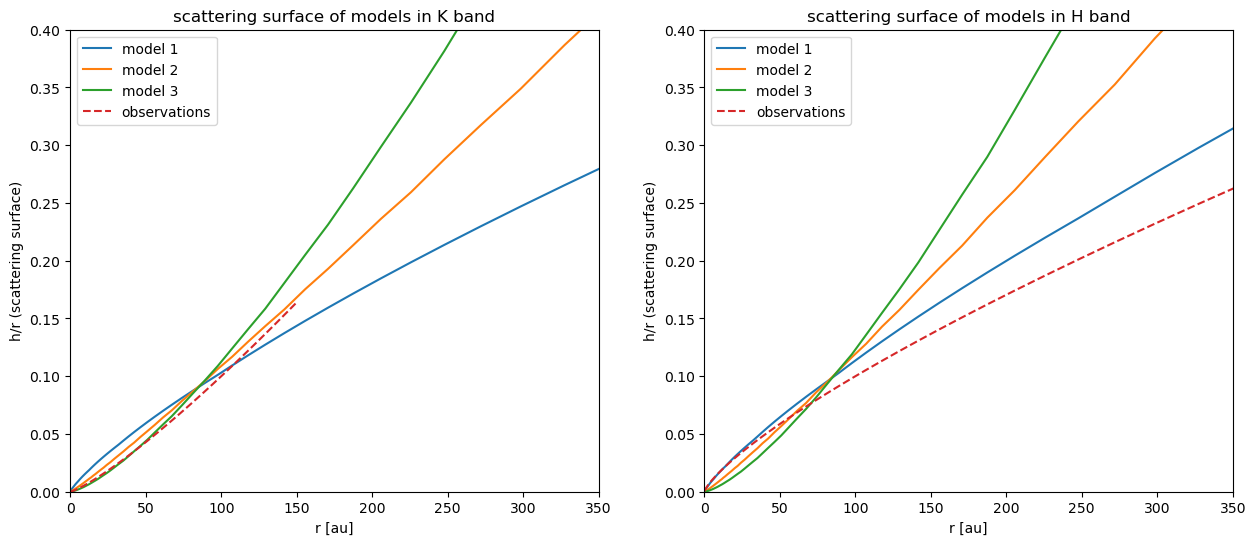

In [187]:
flare_ind = np.array([0.9,1.175, 1.45])
r_planet = 57.3 # au (+8.3-3.3 au) errorbars that we ignore . . .
# h_p is aspect ratio at planet position
h_p_list = np.array([0.02,0.018,0.016])
# h_0_corr is aspect ratio at 100au
h_0_list_corr = np.power(100/r_planet,flare_ind)*h_p_list
print(h_0_list_corr)
tau_scat = 1

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
for i in range(len(flare_ind)):
    r, sigma, h, H= make_model(flare_ind[i], h_0=h_0_list_corr[i], sigma_slope=1.0)
    h_scat = np.array(calc_h_scat(tau_scat, sigma, H, r, kappa=kappa_K))

    plt.plot(r, h_scat/r, label=f"model {i+1}")
    #plt.plot(r, h, label=f"aspect ratio model {i+1}")

r = np.linspace(0,150,100)
plt.plot(r, 0.10*np.power(r/100, 1.22), label="observations", linestyle="dashed")


plt.xlim([0,350])
plt.ylim([0,0.4])
plt.legend()
plt.title("scattering surface of models in K band")
plt.ylabel("h/r (scattering surface)")
plt.xlabel("r [au]")


plt.subplot(1,2,2)
for i in range(len(flare_ind)):
    r, sigma, h, H= make_model(flare_ind[i], h_0=h_0_list_corr[i], sigma_slope=1.0)
    h_scat = np.array(calc_h_scat(tau_scat, sigma, H, r, kappa=kappa_H))

    plt.plot(r, h_scat/r, label=f"model {i+1}")
    #plt.plot(r, h, label=f"aspect ratio model {i+1}")

plt.plot(r, 0.10*np.power(r/100, 0.77), label="observations", linestyle="dashed")


plt.xlim([0,350])
plt.ylim([0,0.4])
plt.legend()
plt.title("scattering surface of models in H band")
plt.ylabel("h/r (scattering surface)")
plt.xlabel("r [au]")


From previous considerations we already know the best flaring indices to fit the observations from the K band and the H band if we assume $h_0 = 0.06$ (at 100 au). Now we want to find out the best $h_p$ at $r = R_p$, because that's what fargo takes as input. Since we're just waving our hands at this point anyway, we assume the general boundaries we set for reasonable values for the flaring index still holds. We now want three models; one that fits pretty well in the K band, one that fits pretty well in the H band, and the sad sad middle. In theory, we could do some elaborate fitting to find the best $h_0$ values, but I'm too lazy so I just eyeballed them with trial-and-error.  (If we wanted to do it really properly, we'd have to fit both values (flaring index and $h_p$) at the same time, and we're not doing something complicated for a bad estimate.) The result of two days of work is this glorious table without legs:

model|1 | 2| 3
----|----|-------|------
flaring index |0.9 | 1.175 | 1.45
$h_p$ | 0.02| 0.018 | 0.016

-_-

Text(0.5, 0, 'r [au]')

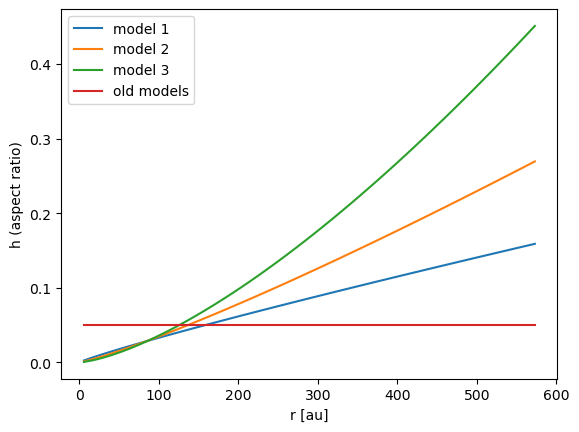

In [188]:
for i in range(len(flare_ind)):
    r = np.linspace(0.1*r_planet, 10*r_planet, 50)
    h = np.power(r/r_planet, flare_ind[i])*h_p_list[i]

    plt.plot(r,h, label=f"model {i+1}")

plt.plot(r, np.power(r/r_planet,0)*0.05, label="old models")
plt.legend()
plt.ylabel("h (aspect ratio)")
plt.xlabel("r [au]")